## Introduccion

Los análisis de normalidad, también llamados contrastes de normalidad, tienen como objetivo analizar si los datos disponibles podrían proceder de una población con una distribución normal. Existen tres estrategias principales abordar este análisis:

*	Representaciones gráficas

*	Métodos analíticos

*	Test de hipótesis.

Uno de los ejemplos más empleados cuando se habla de variables aleatorias que siguen una distribución normal es la altura de las personas. Esta afirmación no es arbitraria, los procesos cuyo resultado es la suma de muchas pequeñas interacciones suelen converger en una distribución normal. La altura de una persona, es el resultado de miles de factores que se suman unos a otros condicionando el crecimiento.

A lo largo del siguiente documento se muestra como utilizar diferentes estrategias para determinar si la altura de un conjunto de personas sigue una distribución normal.


In [ ]:
#Tratamiento de Datos

import pandas as pd
import numpy as np

#Graficos
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import style

#Configurar los Estilos de los graficos
plt.style.use('ggplot')

#Preprocesado y analisis
from scipy import stats
import statsmodels.api as sm

#Configuramos los errores o advertencias
import warnings
warnings.filterwarnings('ignore')

## Datos

Nancy Howell, se trata de informacion de personas que viven en el desierto de Kalahari entre Botsuana, Namibia, Angola. El objetivo es analizar la diferencia entre la varianza del peso de hombre y mujeres

In [ ]:
datos = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/Howell1.csv')
datos.head()

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544 entries, 0 to 543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   height  544 non-null    float64
 1   weight  544 non-null    float64
 2   age     544 non-null    float64
 3   male    544 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 17.1 KB


In [ ]:
#Mujeres que tiene mas de 15 anios

datos = datos[(datos.age > 15) & (datos.male ==1)]
peso = datos['weight']

In [ ]:
len(peso)

174

## Metodos Graficos

Para el analisis de normalidad vamos a representar los datos mediante un histograma y vamos superponer la curva de gauss de la distribuccion normal

In [ ]:
#Formula de Sturges

import math

def sturges_formula(n):
  k = 1 +3.32 * math.log10(n)
  return round(k)

n = 174 # reemplazar con la cantidad de filas del set de datos
num_bins = sturges_formula(n)
print('Numero de bines segun la formula de Sturges es: ', num_bins)

Numero de bines segun la formula de Sturges es:  8


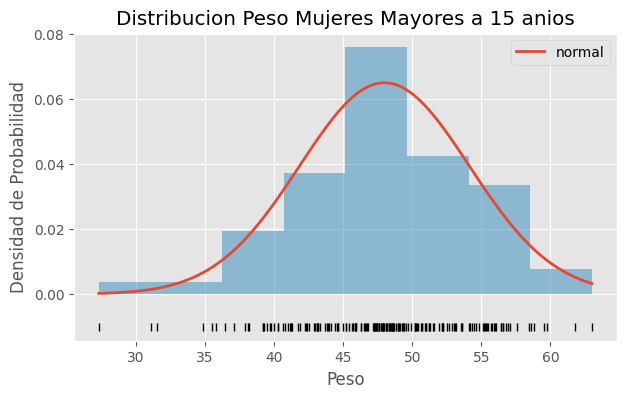

In [ ]:
## Histograma + curva normal teorica

#Valores de la media (mu) y desviacion estandar (sigma) de los datos

mu, sigma = stats.norm.fit(peso)

#Valores Teorico de la normaliadd del rango observado
x_hat = np.linspace(min(peso), max(peso), num = 100)
y_hat = stats.norm.pdf(x_hat, mu , sigma)

#Grafico
fig, ax = plt.subplots(figsize = (7,4))
ax.plot(x_hat, y_hat , linewidth = 2, label = 'normal')
ax.hist(x = peso, density= True, bins=num_bins, alpha = 0.5)
ax.plot(peso,np.full_like(peso,-0.01),'|k',markeredgewidth = 1)
ax.set_title('Distribucion Peso Mujeres Mayores a 15 anios')
ax.set_xlabel('Peso')
ax.set_ylabel('Densidad de Probabilidad')
#ax.annotate('mu', [60,0.08])
ax.legend()
plt.show()


QQ PLOT

Compara los cuantiles de la distibucion observada, los cuantiles teoricos de una distribucion normal deben tener una misma media y desviacion estandar, cuanto mas esten alineados los datos a una distribucion normal, mas cerca estan los puntos de la recta.

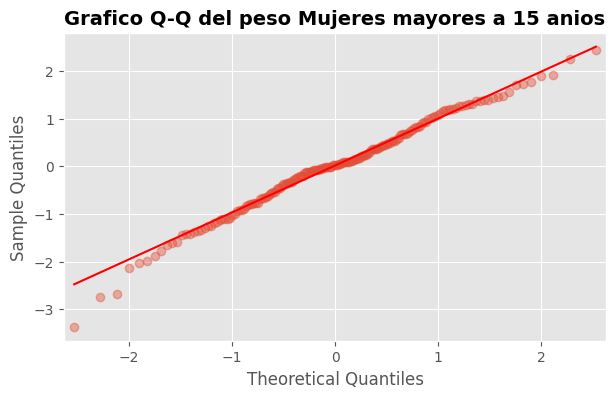

In [ ]:
# Grafico Q-Q

fig, ax = plt.subplots(figsize = (7,4))

sm.qqplot(
    peso,
    fit = True,
    line = 'q',
    alpha = 0.4,
    lw = 2,
    ax = ax
)
ax.set_title('Grafico Q-Q del peso Mujeres mayores a 15 anios', fontsize = 14, fontweight = 'bold')
plt.show()

# Metodo Analitcos Asimetria y Curtosis

Los estadisticos de Asimetria y Curtosis pueden emplearse para detectar las desviaciones de la normalidad. Un valor de la curtosis o coeficiente de asimetria entre -1 y 1 , es generalmente considerada una ligera desviacion de la normalidad. Entre -2 y 2 hay una desviacion de la normalidad pero no extrema.

In [ ]:
print('Asimetria:',stats.skew(peso)) #simetria
print('Curtosis:', stats.kurtosis(peso)) #kurtosis

Asimetria: -0.3307819277008199
Curtosis: 0.29372818889735397


## Contrastes de Hipotesis

Los test Shapiro-Wilk test y D'Agostino's K-squared test son dos de los test de hipótesis más empleados para analizar la normalidad. En ambos, se considera como hipótesis nula que los datos proceden de una distribución normal.

* HO: Los datos siguen una distribucion Normal
* H1: Los datos **NO** siguen una distribucion normal

P-Value: Nos indica la probabilidad de obtener los datos observados si los datos realmente fueran normales: Y se interpreta asi:

Si p >0.05 --> No hay evidencia suficiente para rechazar la Hipotesis Nula. Los datos pueden ser normales.

Si p <=0.05 Rechazamos la  H0, los datos **NO SON NORMALES**

El p-value de estos test indica la probabilidad de obtener unos datos como los observados si realmente procediesen de una población con una distribución normal con la misma media y desviación que estos. Por lo tanto, si el p-value es menor que un determinado valor (típicamente 0.05), entonces se considera que hay evidencias suficientes para rechazar la normalidad.

El test de Shapiro-Wilk se desaconseja cuando se dispone de muchos datos (más de 50) por su elevada sensibilidad a pequeñas desviaciones de la normal.

In [ ]:
# Shapiro-Wilk test = w = 1
shapiro_test = stats.shapiro(peso)
shapiro_test

ShapiroResult(statistic=0.9898969381862256, pvalue=0.25420307409327825)

In [ ]:
# D'Agostino's K-squared test

k2, p_value = stats.normaltest(peso)
print(f'Estadistico: {k2}, p-value: {p_value}')

Estadistico: 4.2576307260933834, p-value: 0.11897815632110778


Ninguno de los test muestra evidencias para rechazar la hipotesis de que los datos se distribuyen de forma normal

## Consecuencias de la falta de normalidad


El hecho de no poder asumir la normalidad influye principalmente en los test de hipótesis paramétricos (t-test, anova,…) y en los modelos de regresión. Las principales consecuencias de la falta de normalidad son:

* Los estimadores mínimo-cuadráticos no son eficientes (de mínima varianza).

* Los intervalos de confianza de los parámetros del modelo y los contrastes de significancia son solamente aproximados y no exactos.

Los test estadísticos expuestos requieren que la población de la que procede la muestra tenga una distribución normal, no la muestra en sí. Si la muestra se distribuye de forma normal, se puede aceptar que así lo hace la población de origen. En el caso de que la muestra no se distribuya de forma normal pero se tenga certeza de que la población de origen sí lo hace, entonces, puede estar justificado aceptar los resultados obtenidos por los contrastes paramétricos como válidos.


El valor de P es el resultado de la prueba de hipotesis: Si el varlo de P es menor que el nivel de significancia elegido (a menudo 0.05),entonces se rechaza la hipotesis nula, por ende se acepta la alternativa y se concluiria que los datos no se distribuyen de forma normal. Si el valor de P es mayor al nivel de significancia (0.05),entonces se acepta la hipotesis nula, de lo que los datos estan distribuidos de forma normal y se rechaza la alternativa.